# NB18 — Bayesian Linear Regression

> **StatQuest: "Instead of asking 'what is the slope?', Bayesian regression asks 'what distribution of slopes is consistent with the data?'"**

---

## The main ideas:

1. Frequentist: b1 is a fixed (unknown) constant — we estimate it
2. Bayesian: b1 is a **random variable** — we assign a prior and update with data
3. **Prior** = what we believe before seeing data
4. **Likelihood** = probability of data given parameters
5. **Posterior** = prior updated by data (via Bayes' theorem)
6. Output: not a single b1, but a **distribution** over b1 — captures uncertainty naturally


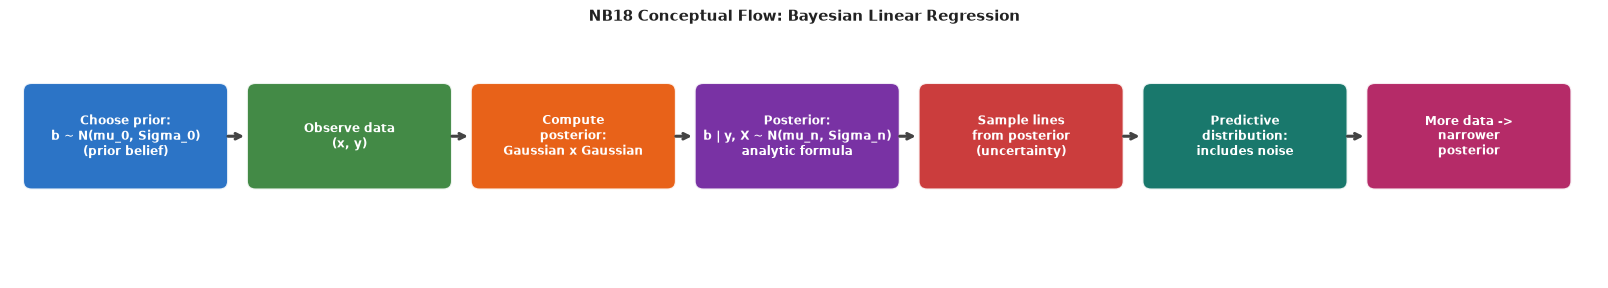

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Choose prior:\nb ~ N(mu_0, Sigma_0)\n(prior belief)',
        'Observe data\n(x, y)',
        'Compute\nposterior:\nGaussian x Gaussian',
        'Posterior:\nb | y, X ~ N(mu_n, Sigma_n)\nanalytic formula',
        'Sample lines\nfrom posterior\n(uncertainty)',
        'Predictive\ndistribution:\nincludes noise',
        'More data ->\nnarrower\nposterior',
    ],
    title='NB18 Conceptual Flow: Bayesian Linear Regression',
    colors=['#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828','#00695C','#AD1457'],
    figsize=(16, 2.8),
)


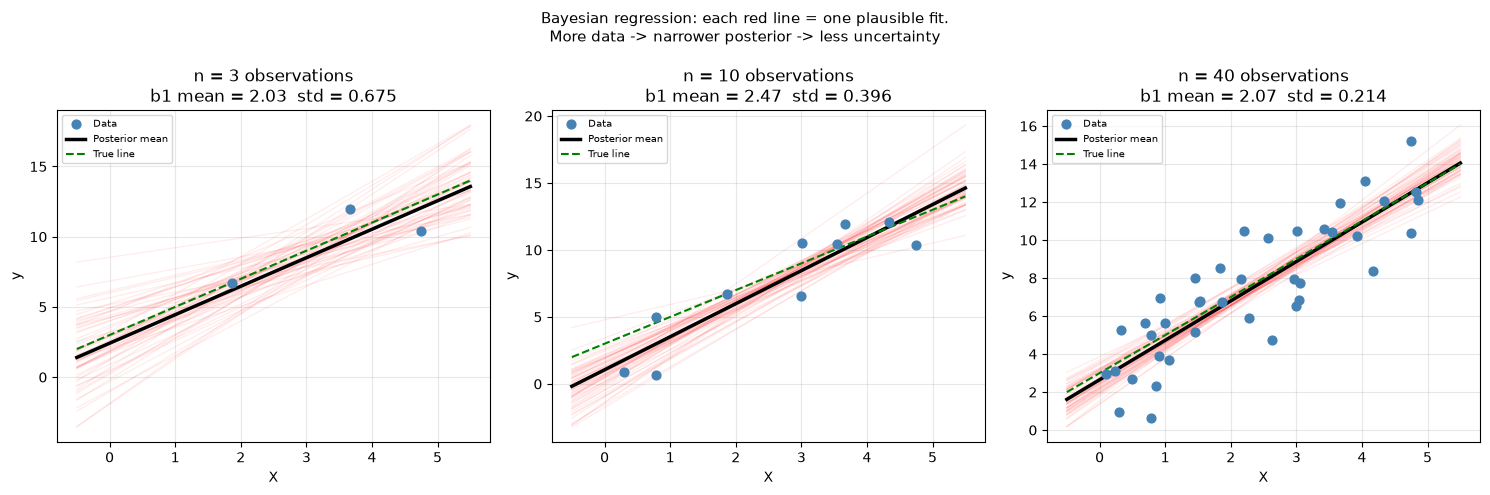

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
true_b0, true_b1, sigma = 3.0, 2.0, 2.0
n_total = 40
X_all = np.random.uniform(0, 5, n_total)
y_all = true_b0 + true_b1*X_all + np.random.normal(0, sigma, n_total)

def bayesian_lr_posterior(X, y, sigma2_noise, mu_0, Sigma_0_inv):
    """Conjugate Gaussian-Gaussian posterior for linear regression."""
    X_d        = np.column_stack([np.ones(len(X)), X])
    Sigma_n_inv = Sigma_0_inv + X_d.T @ X_d / sigma2_noise
    Sigma_n     = np.linalg.inv(Sigma_n_inv)
    mu_n        = Sigma_n @ (Sigma_0_inv @ mu_0 + X_d.T @ y / sigma2_noise)
    return mu_n, Sigma_n

mu_0        = np.array([0., 0.])
Sigma_0_inv = np.eye(2) / 10.0   # weakly informative prior: variance = 10

X_plot = np.linspace(-0.5, 5.5, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n_obs in zip(axes, [3, 10, 40]):
    X_sub  = X_all[:n_obs]; y_sub = y_all[:n_obs]
    mu_n, Sigma_n = bayesian_lr_posterior(X_sub, y_sub, sigma**2, mu_0, Sigma_0_inv)

    # Draw 60 lines from the posterior
    samples = np.random.multivariate_normal(mu_n, Sigma_n, 60)
    ax.scatter(X_sub, y_sub, color='steelblue', s=40, zorder=3, label='Data')
    for s in samples:
        ax.plot(X_plot, s[0]+s[1]*X_plot, 'r-', alpha=0.07, linewidth=1)
    ax.plot(X_plot, mu_n[0]+mu_n[1]*X_plot, 'k-', linewidth=2.5, label='Posterior mean')
    ax.plot(X_plot, true_b0+true_b1*X_plot, 'g--', linewidth=1.5, label='True line')
    ax.set_title(f'n = {n_obs} observations\nb1 mean = {mu_n[1]:.2f}  std = {Sigma_n[1,1]**0.5:.3f}')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_xlabel('X'); ax.set_ylabel('y')

plt.suptitle('Bayesian regression: each red line = one plausible fit.\n'
             'More data -> narrower posterior -> less uncertainty', fontsize=11)
plt.tight_layout(); plt.show()


## Connection to Ridge regression

With a Gaussian prior `b ~ N(0, I/lambda)`:

```
Posterior MAP estimate  =  argmax p(b | y, X)
                        =  argmin  SSR + lambda * sum(b_j^2)
                        =  Ridge regression!
```

**Ridge is Bayesian MAP with a Gaussian prior.**
The lambda in Ridge = 1/prior_variance in Bayesian language.


In [3]:
# Show that Bayesian MAP = Ridge with matching lambda
import numpy as np
from sklearn.linear_model import Ridge

np.random.seed(1)
n = 50
X_r = np.random.randn(n, 3)
y_r = 2*X_r[:,0] - X_r[:,1] + np.random.normal(0, 1, n)

lam = 1.0   # Ridge lambda
prior_var = 1/lam  # Bayesian prior variance

X_d   = np.column_stack([np.ones(n), X_r])
Sigma_0_inv = np.eye(4) / prior_var
Sigma_0_inv[0,0] = 0  # don't penalise intercept
mu_0  = np.zeros(4)

mu_n, Sigma_n = bayesian_lr_posterior(X_r, y_r, sigma2_noise=1.0,
                                       mu_0=mu_0, Sigma_0_inv=Sigma_0_inv)

ridge = Ridge(alpha=lam).fit(X_r, y_r)
print("Bayesian MAP b1,b2,b3:", np.round(mu_n[1:], 5))
print("Ridge        b1,b2,b3:", np.round(ridge.coef_, 5))
print("Match:", np.allclose(mu_n[1:], ridge.coef_, atol=0.01))
print("\nRidge = Bayesian MAP with a Gaussian prior (variance = 1/lambda)")


Bayesian MAP b1,b2,b3: [ 2.26981 -0.74375  0.22371]
Ridge        b1,b2,b3: [ 2.26981 -0.74375  0.22371]
Match: True

Ridge = Bayesian MAP with a Gaussian prior (variance = 1/lambda)


## Key Takeaways

| | Frequentist OLS | Bayesian |
|--|----------------|---------|
| Output | Point estimate b_hat | Full posterior distribution |
| Uncertainty | From t-distribution (large n) | Directly from posterior |
| Prior knowledge | Not used | Incorporated naturally |
| Small n | Can give wide CI | Prior regularises |
| Equivalent to | OLS | Ridge (with Gaussian prior, MAP) |

**Next: NB19 — applying linear regression to time-series data.**
